# Netflix Content Strategy Analysis (2008–2021)

## Introduction

This project analyzes how Netflix has evolved its content strategy over time using a dataset of movies and TV shows available on the platform.

The analysis focuses on identifying patterns in:
- Content type (Movies vs TV Shows)
- Genre distribution
- Global content expansion

The goal is to derive data-driven insights into Netflix’s strategic decisions and suggest potential future directions.

## Problem Statement

The objective of this analysis is to understand how Netflix’s content strategy has evolved between 2008 and 2021.

Key questions addressed in this project:

- What type of content dominates the platform (Movies vs TV Shows)?
- Has Netflix shifted its focus toward TV Shows over time?
- What genres are most commonly produced?
- Is Netflix expanding its content globally?

By answering these questions, we aim to uncover strategic patterns in Netflix’s content decisions.

## Dataset Overview

The dataset contains information about movies and TV shows available on Netflix.

Key columns used in this analysis:

- **type**: Indicates whether the content is a Movie or TV Show  
- **title**: Name of the content  
- **country**: Country of production  
- **date_added**: Date when the content was added to Netflix  
- **release_year**: Year of original release  
- **listed_in**: Categories/genres of the content  
- **duration**: Duration in minutes or number of seasons  

These features are used to analyze content distribution, trends over time, and regional patterns.

In [13]:
import pandas as pd

df = pd.read_csv("E:\\DataScience\\Netflix_Content_Strategy_Analyisis\\data\\netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


## Data Cleaning

The dataset contains missing values and inconsistent formats that need to be handled before analysis.

Key steps performed:

- Handling missing values in columns such as director, cast, country, rating, and duration  
- Cleaning and converting the `date_added` column into datetime format  
- Creating a new column `year_added` for time-based analysis  

These steps ensure that the dataset is consistent and suitable for analysis.

In [15]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')
df['duration'] = df['duration'].fillna('Unknown')

In [16]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [17]:
df = df.dropna(subset=['date_added'])

In [18]:
df['year_added'] = df['date_added'].dt.year

In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   str           
 1   type          8797 non-null   str           
 2   title         8797 non-null   str           
 3   director      8797 non-null   str           
 4   cast          8797 non-null   str           
 5   country       8797 non-null   str           
 6   date_added    8797 non-null   datetime64[us]
 7   release_year  8797 non-null   int64         
 8   rating        8797 non-null   str           
 9   duration      8797 non-null   str           
 10  listed_in     8797 non-null   str           
 11  description   8797 non-null   str           
 12  year_added    8797 non-null   int32         
dtypes: datetime64[us](1), int32(1), int64(1), str(10)
memory usage: 927.8 KB


## Content Type Distribution

This section analyzes the distribution of Movies and TV Shows available on Netflix.

In [20]:
df['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

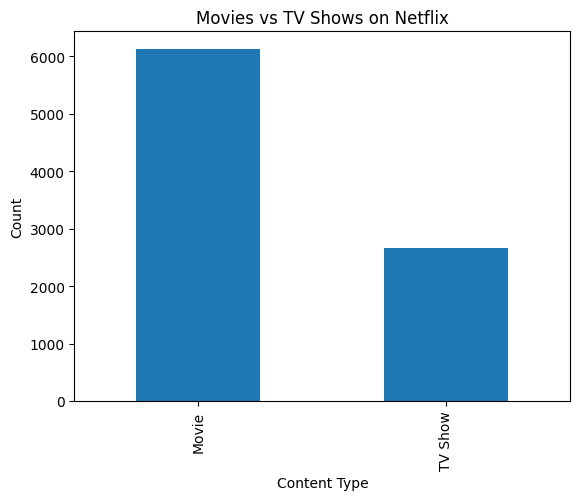

In [21]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

### Insight

The dataset shows that Movies dominate Netflix’s content library, accounting for a significantly larger proportion compared to TV Shows.

This suggests that Netflix has historically focused on Movies, likely due to their scalability and faster production/acquisition compared to episodic content.

## Content Trend Over Time

This section analyzes how the number of Movies and TV Shows added to Netflix has changed over the years.

In [22]:
trend = df.groupby(['year_added', 'type']).size().unstack()


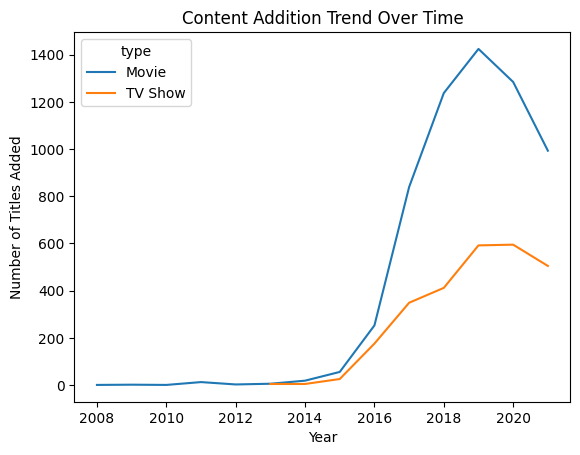

In [23]:
trend.plot()
plt.title("Content Addition Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.show()

### Insight

The trend shows a sharp increase in content additions after 2015, with a particularly strong rise in TV Shows.

For example, TV Shows increased significantly between 2015 and 2016, indicating a shift in Netflix’s content strategy toward episodic formats.

This suggests that Netflix began investing more heavily in TV Shows during its global expansion phase, likely to enhance long-term user engagement.

## Genre Analysis

This section explores the most common genres available on Netflix to understand content preferences.

In [24]:
genres = df['listed_in'].str.split(', ').explode().value_counts()
genres.head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

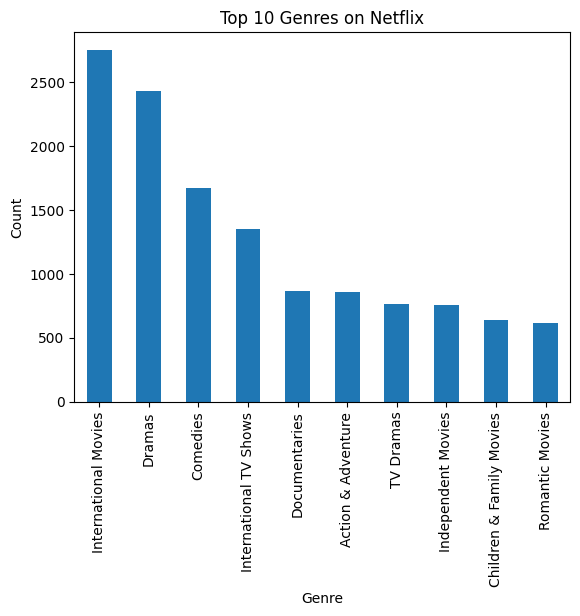

In [25]:
genres.head(10).plot(kind='bar')
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

### Insight

The analysis shows that genres such as Drama, Comedy, and Action are among the most common on Netflix.

Additionally, the presence of “International Movies” as a dominant category indicates a strong focus on globally diverse content.

This suggests that Netflix prioritizes widely appealing genres to maximize audience reach while also investing in international content to support global expansion.

## Country Analysis

This section analyzes the distribution of content across different countries to understand Netflix’s global presence.

In [26]:
countries = df['country'].value_counts()
countries.head(10)

country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

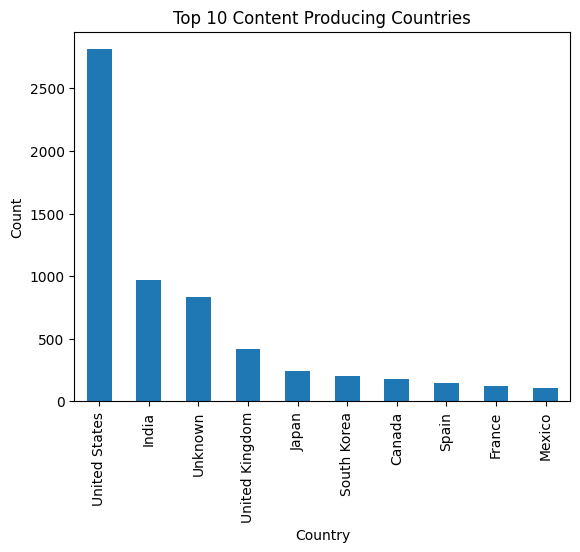

In [27]:
countries.head(10).plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

### Insight

The United States contributes the largest share of content on Netflix, indicating its continued dominance in production.

However, countries such as India, the United Kingdom, Japan, and South Korea also appear among the top contributors.

This suggests that Netflix has expanded beyond a US-centric model and is actively investing in regional content to support its global audience.

## Conclusion

This analysis of Netflix’s content from 2008 to 2021 reveals a clear evolution in its content strategy.

- Netflix’s library is dominated by Movies, indicating a focus on scalable and easily distributable content.
- After 2015, there is a significant increase in TV Shows, suggesting a strategic shift toward episodic content.
- Popular genres such as Drama, Comedy, and Action dominate the platform, reflecting a mass-audience content approach.
- The presence of countries like India, Japan, and South Korea highlights Netflix’s expansion into global markets.

Overall, Netflix appears to have followed a balanced strategy—starting with safe, scalable content and gradually expanding into TV Shows and international productions.

Going forward, continued investment in episodic content and regional markets could further enhance user engagement and global reach.